In [2]:
from datasets import load_dataset
import pandas as pd


/Users/shubhamprashar/Downloads/webserver/venv/include/python3.12/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/shubhamprashar/Downloads/webserver/venv/include/python3.12/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("banking77")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [4]:
# as we can see in the above cell, this dataset already comes pre-splitted into training and test
sample = dataset["train"][0]
label_names = dataset["train"].features["label"].names
print("query = ", sample["text"])
print("intent_index =", sample["label"])
print("intext string =", label_names[sample["label"]])

query =  I am still waiting on my card?
intent_index = 11
intext string = card_arrival


In [5]:
# checking the intent strings
for intent in label_names:
    print(intent)

activate_my_card
age_limit
apple_pay_or_google_pay
atm_support
automatic_top_up
balance_not_updated_after_bank_transfer
balance_not_updated_after_cheque_or_cash_deposit
beneficiary_not_allowed
cancel_transfer
card_about_to_expire
card_acceptance
card_arrival
card_delivery_estimate
card_linking
card_not_working
card_payment_fee_charged
card_payment_not_recognised
card_payment_wrong_exchange_rate
card_swallowed
cash_withdrawal_charge
cash_withdrawal_not_recognised
change_pin
compromised_card
contactless_not_working
country_support
declined_card_payment
declined_cash_withdrawal
declined_transfer
direct_debit_payment_not_recognised
disposable_card_limits
edit_personal_details
exchange_charge
exchange_rate
exchange_via_app
extra_charge_on_statement
failed_transfer
fiat_currency_support
get_disposable_virtual_card
get_physical_card
getting_spare_card
getting_virtual_card
lost_or_stolen_card
lost_or_stolen_phone
order_physical_card
passcode_forgotten
pending_card_payment
pending_cash_withdraw

In [6]:

## We want to convert the dataset into pandas df for easier exploration with provided methods
train_df = dataset["train"].to_pandas()

In [7]:
## Figuring out how many examples per intent we have
print(train_df["label"].value_counts().sort_index())

label
0     159
1     110
2     126
3      87
4     127
     ... 
72     41
73    135
74    121
75    180
76    163
Name: count, Length: 77, dtype: int64


In [8]:
train_df["label"].value_counts(normalize=True) * 100

label
15    1.869439
28    1.819454
6     1.809457
75    1.799460
19    1.769469
        ...   
41    0.819754
18    0.609817
10    0.589823
72    0.409877
23    0.349895
Name: proportion, Length: 77, dtype: float64

<Axes: xlabel='label'>

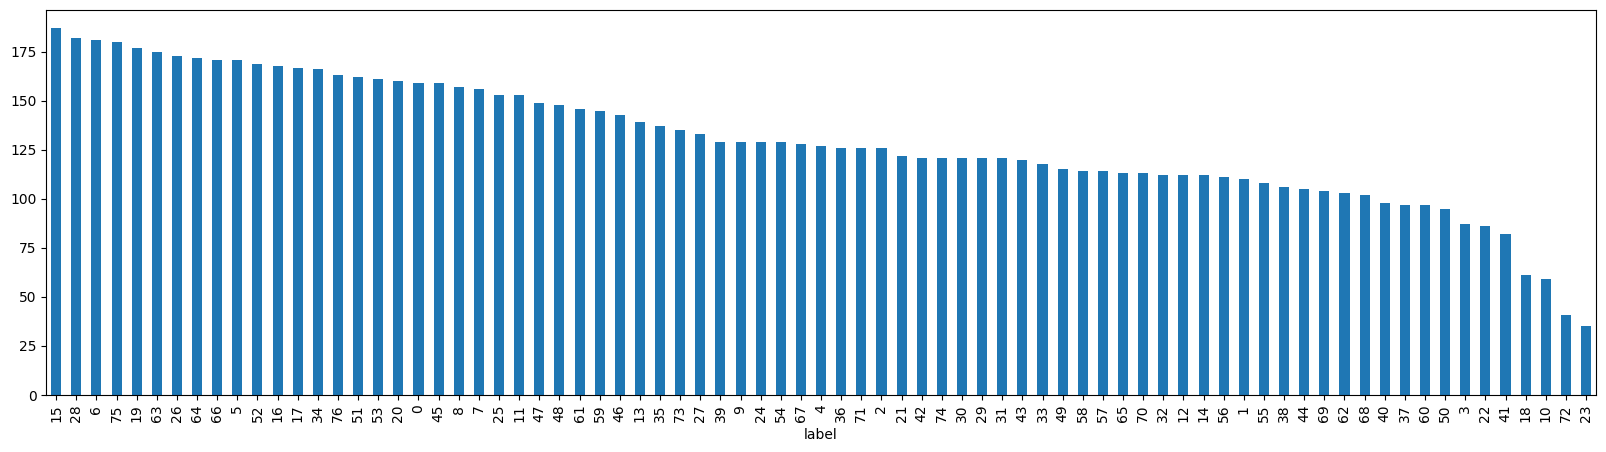

In [9]:
train_df["label"].value_counts().plot(kind="bar", figsize=(20, 5))

In [10]:
## Lets compute the mean and median of the number of examples per label
## This is the average class size
## This tells use that on average how many examples we have for labels

counts = train_df["label"].value_counts()
print(counts.mean()) 
print(counts.median())
print(counts.min())
print(counts.max())
print(counts.quantile(0.95))

129.9090909090909
127.0
35
187
177.60000000000002


In [11]:
## Now we should also analyse the query strings

# text_list = []
# for text in train_df["text"]:
#     text_list.append(text.split())

# print(text_list[0])

# the above code can be done smartly to the data_frame and save it in a new col

train_df["text_len"] = train_df["text"].apply(lambda x: len(x.split()))

 
print(train_df["text_len"].mean())
print(train_df["text_len"].median())
print(train_df["text_len"].quantile(0.95))
print(train_df["text_len"].min())
print(train_df["text_len"].max())



11.949415175447365
10.0
29.0
2
79


ran


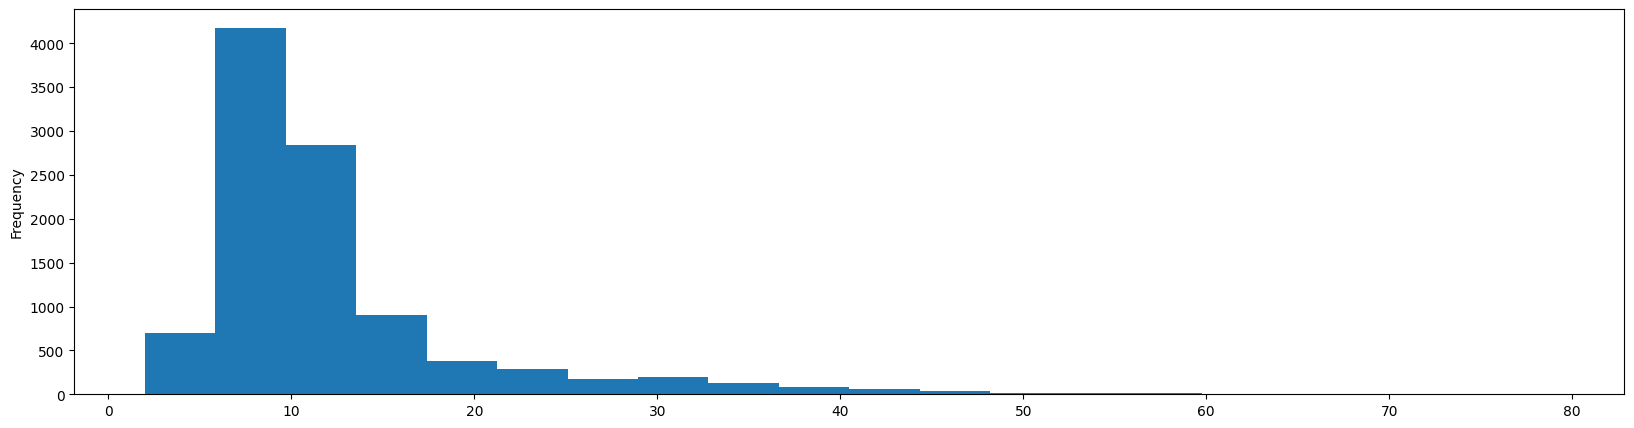

In [16]:

# since we will be working with NLP techniques, len is important for tokenisation
train_df["text_len"].plot(kind="hist", bins = 20, figsize=(20, 5))